# Chapter 5, Example 2b
## 3-fold cross-validation to determine the optimum number of hidden neurons on Iris dataset

In [1]:
import torch
from torch import nn

from sklearn import datasets
from sklearn.model_selection import KFold

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class FFN(nn.Module):
    def __init__(self, no_features, hidden_units, no_labels):
        super().__init__()
        self.relu_stack = nn.Sequential(
            nn.Linear(no_features, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, no_labels),
        )

    def forward(self, x):
        logits = self.relu_stack(torch.tensor(x, dtype=torch.float32))
        return logits

In [3]:
def train_exp(rseed, X, Y, no_folds, no_features, hidden_units, no_labels, no_epochs, lr):

   # generates train and test indices to split a dataset into k consecutive parts 
    cv = KFold(n_splits=no_folds, shuffle=True, random_state=rseed)
    
    loss_fn = torch.nn.CrossEntropyLoss()
    
    acc = []
    for train_idx, test_idx in cv.split(X, Y):
        x_train, y_train  = X[train_idx], Y[train_idx]
        x_test, y_test = X[test_idx], Y[test_idx]

        acc_ = []
        for no_hidden in hidden_units:
        
            model = FFN(no_features, no_hidden, no_labels)
    
            optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
            for epoch in range(no_epochs):
                pred = model(x_train)
                loss = loss_fn(pred, torch.tensor(y_train, dtype=torch.long))
    
                # Backpropagation
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
            pred = model(x_test)
            acc__ = (pred.argmax(1) == y_test).type(torch.float).mean()
    
            acc_.append(acc__.item())

        acc.append(acc_)
    
    cv_acc = np.mean(np.array(acc), axis = 0)
        
    return cv_acc

In [4]:
# read data
iris = datasets.load_iris()

no_features = np.shape(iris.data)[1]
no_labels = len(np.unique(iris.target))

# center the data
X = iris.data - np.mean(iris.data, axis=0)

Y = iris.target

In [5]:
lr = 0.1
no_epochs = 1000

hidden_units = [2, 4, 6, 8, 10, 12]

no_folds = 3
no_exps = 10

seed = 10
torch.manual_seed(seed)
np.random.seed(seed)

In [6]:
acc = []
for exp in range(no_exps):
        
    acc.append(train_exp(exp, X, Y, no_folds, no_features, hidden_units, no_labels, no_epochs, lr))
    print('exp %d, cv acc %s'%(exp, np.round(acc[exp], 3)))

mean_acc = np.mean(np.array(acc), axis = 0)
print('mean accuracy %s'%np.round(mean_acc, 4))
print('* hidden units %d *'%hidden_units[np.argmax(mean_acc)])

exp 0, cv acc [0.973 0.967 0.973 0.973 0.973 0.973]
exp 1, cv acc [0.973 0.967 0.967 0.967 0.967 0.967]
exp 2, cv acc [0.727 0.967 0.967 0.967 0.967 0.967]
exp 3, cv acc [0.96  0.953 0.953 0.947 0.953 0.953]
exp 4, cv acc [0.953 0.967 0.967 0.96  0.953 0.96 ]
exp 5, cv acc [0.7   0.98  0.98  0.98  0.973 0.98 ]
exp 6, cv acc [0.887 0.973 0.967 0.973 0.967 0.967]
exp 7, cv acc [0.86 0.96 0.96 0.96 0.96 0.96]
exp 8, cv acc [0.967 0.967 0.967 0.967 0.967 0.967]
exp 9, cv acc [0.98  0.967 0.973 0.973 0.98  0.967]
mean accuracy [0.898  0.9667 0.9673 0.9667 0.966  0.966 ]
* hidden units 6 *


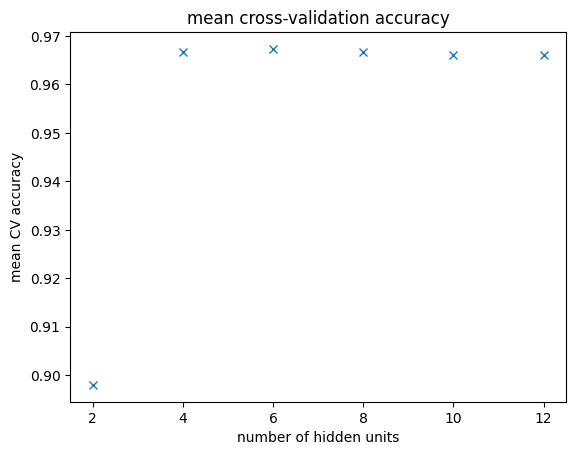

In [7]:
plt.figure(1)
plt.plot(hidden_units, mean_acc, marker = 'x', linestyle = 'None')
plt.title('mean cross-validation accuracy')
plt.xlabel('number of hidden units')
plt.ylabel('mean CV accuracy')
plt.show()